### **Lembar Kerja Praktikum:**

*   Mata Kuliah :BDDM
*   Pertemuan Ke : 16
*   CPMK: Mahasiswa Mampu Menerapkan Metode Analisis Data (CPMK 21)
*   Sub CPMK: Mahasiswa dapat menjelaskan supervised learning - klasifikasi
*   Indikator Keberhasilan: Mahasiswa dapat mengimplementasikan algoritma naive bayes dalam bahasa pemrograman

### **Identitas Praktikan:**
Nama: Yezha Amanando Rifky Zafian
<br>
Nim: 23.11.5629
<br>
Kelas: IF05

### **Petunjuk Kerja**

1. Gunakan Dataset Berikut: [Link Dataset](https://drive.google.com/file/d/1N-Y-HTGt42x1PgZDJ8wONG1StMBCgMV_/view?usp=sharing)
2. Buatlah Model Naive bayes untuk memprediksi Apakah seseorang akan meninggal/ bertahan hidup dengan beberapa gejala yang ia miliki.
3. Lakukan Analisa dari model yang anda peroleh
4. Tulis code program anda Pada Bagian yang telah disedikan, boleh menambah baris code
5. Durasi Pengerjaan 60 menit
6. Jika sudah selesai, download **model** dan **file notebook**  anda dan letakkan di desktop masing-masing


### **Ketentuan penggunaan AI:**

*   diperbolehkan menggunakan AI untuk debugging
*   diperbolehkan menggunakan AI untuk membantu memahami teori


### **Pernyataan Penggunaan AI:**
Saya menggunakan Chatgpt/gemini (tulis nama AI yang anda gunakan) untuk .....namun seluruh kode dan hasil eksperimen merupakan pekerjaan saya sendiri

### **1. Import Library**

In [ ]:
# tuliskan library yang anda butuhkan disini
# import library
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

### **2.  Load Data**

In [ ]:
# tuliskan code untuk load data
df = pd.read_csv('/content/Tugas-8.csv')

In [ ]:
# tampilkan sampel data
df.head()


,age,sex,steroid,antivirals,fatigue,malaise,anorexia,liver_big,liver_firm,spleen_palpable,spiders,ascites,varices,bilirubin,alk_phosphate,sgot,albumin,protime,histology,class
0,30,male,False,False,False,False,False,False,False,False,False,False,False,1.0,85.0,18.0,4.0,NaN,False,live
1,50,female,False,False,True,False,False,False,False,False,False,False,False,0.9,135.0,42.0,3.5,NaN,False,live
2,78,female,True,False,True,False,False,True,False,False,False,False,False,0.7,96.0,32.0,4.0,NaN,False,live
3,31,female,NaN,True,False,False,False,True,False,False,False,False,False,0.7,46.0,52.0,4.0,80.0,False,live
4,34,female,True,False,False,False,False,True,False,False,False,False,False,1.0,NaN,200.0,4.0,NaN,False,live


### **3. Preprocessing**

In [ ]:
# tuliskan code untuk preprecessing
# Copy dataset
data = df.copy()

# List of columns that should be treated as boolean and converted to 0/1
# Based on df.info(), these are mostly object Dtype but contain True/False, some are bool Dtype
boolean_like_cols = ['steroid', 'fatigue', 'malaise', 'anorexia', 'liver_big', 'liver_firm',
                     'spleen_palpable', 'spiders', 'ascites', 'varices', 'antivirals', 'histology']

for col in boolean_like_cols:
    if col in data.columns:
        # Convert True to 1, False to 0. NaN values will remain NaN.
        # .replace() handles both boolean True/False and string 'True'/'False'
        data[col] = data[col].replace({True: 1, False: 0, 'True': 1, 'False': 0})
        # Ensure the column is numeric, coercing any other values to NaN if they exist
        data[col] = pd.to_numeric(data[col], errors='coerce')

# Encode kolom sex
if 'sex' in data.columns:
    le = LabelEncoder()
    data['sex'] = le.fit_transform(data['sex'])

# Encode target class
data['class'] = data['class'].str.lower().map({'live':1,'die':0})

# Pisahkan fitur dan target
X = data.drop('class', axis=1)
y = data['class']

# Imputasi missing value (median)
# Now all relevant columns should be numerical (int or float) with NaNs, ready for imputation.
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X) # This returns a numpy array with imputed values

# Reconstruct DataFrame with original column names
X = pd.DataFrame(X_imputed, columns=X.columns)

/tmp/ipython-input-257285354.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[col] = data[col].replace({True: 1, False: 0, 'True': 1, 'False': 0})


## **4. Fitur Selection**

In [ ]:
# lakukan fitur selection menggunakan correlation
# Gabungkan kembali X dan y
df_corr = pd.concat([X, y], axis=1)

# Hitung korelasi ke target
corr = df_corr.corr()['class'].sort_values(ascending=False)

corr

,class
class,1.000000
albumin,0.455927
protime,0.307278
sex,0.173051
steroid,0.137413
antivirals,0.130196
liver_firm,-0.020057
sgot,-0.069572
liver_big,-0.093665
alk_phosphate,-0.125083


Jika memilih fitur berdasarkan korelasi

In [ ]:
selected_features = corr[abs(corr) > 0.05].index.tolist()
selected_features.remove('class')

X_selected = X[selected_features]

X_selected.head()


,albumin,protime,sex,steroid,antivirals,sgot,liver_big,alk_phosphate,anorexia,age,spleen_palpable,fatigue,histology,malaise,varices,spiders,bilirubin,ascites
0,4.0,61.0,1.0,0.0,0.0,18.0,0.0,85.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,3.5,61.0,0.0,0.0,0.0,42.0,0.0,135.0,0.0,50.0,0.0,1.0,0.0,0.0,0.0,0.0,0.9,0.0
2,4.0,61.0,0.0,1.0,0.0,32.0,1.0,96.0,0.0,78.0,0.0,1.0,0.0,0.0,0.0,0.0,0.7,0.0
3,4.0,80.0,0.0,1.0,1.0,52.0,1.0,46.0,0.0,31.0,0.0,0.0,0.0,0.0,0.0,0.0,0.7,0.0
4,4.0,61.0,0.0,1.0,0.0,200.0,1.0,85.0,0.0,34.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


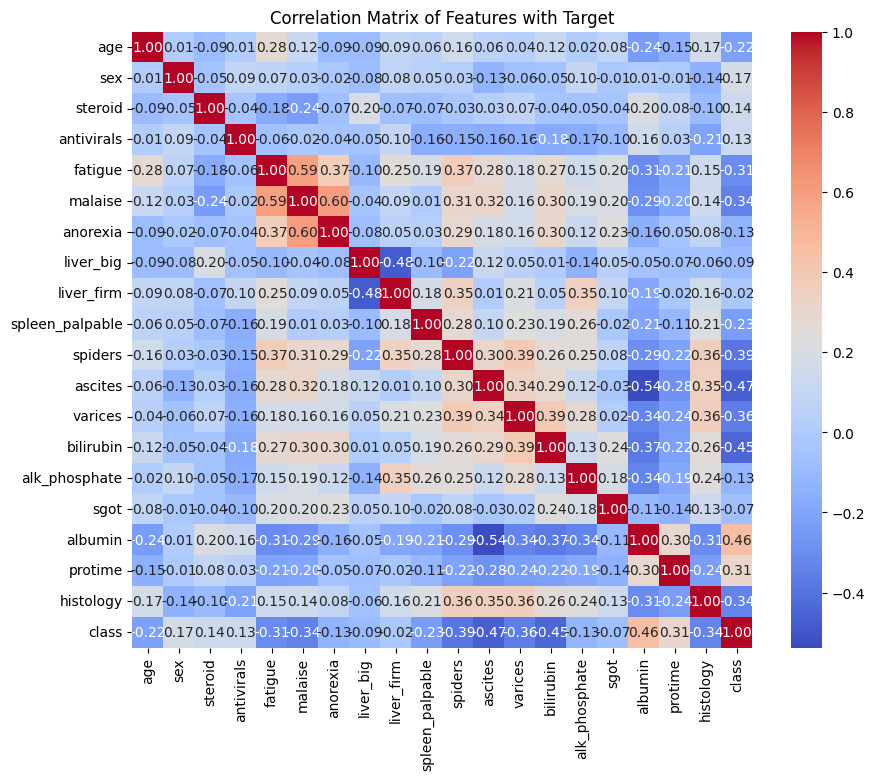

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_matrix = df_corr.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features with Target')
plt.show()

### **5. Spliting**

In [ ]:
# lakukan splitting dengan perbandingan train:test, 70:30
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

### **6. Modelling**

In [ ]:
##lakukan modeling menggunakan gaussian naive bayes
# Standarisasi
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
model = GaussianNB()
model.fit(X_train_scaled, y_train)

GaussianNB()

### **7. Evaluasi Model**

In [ ]:
# lakukan evaluasi model anda
y_pred = model.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.6170212765957447
Precision: 1.0
Recall   : 0.5135135135135135
F1 Score : 0.6785714285714286

Confusion Matrix:
[[10  0]
 [18 19]]

Classification Report:
              precision    recall  f1-score   support

           0       0.36      1.00      0.53        10
           1       1.00      0.51      0.68        37

    accuracy                           0.62        47
   macro avg       0.68      0.76      0.60        47
weighted avg       0.86      0.62      0.65        47



### **8. Simpan Model Anda**

In [ ]:
# simpan model anda
#pastikan anda mendownload model anda
joblib.dump({
    'model': model,
    'scaler': scaler,
    'features': selected_features
}, '/content/model_gnb_70_30.joblib')

print("Model disimpan sebagai model_gnb_70_30.joblib")

Model disimpan sebagai model_gnb_70_30.joblib


### **9. Ulangi Langkah 5-8**

gunakan spliting 75:25

spliting

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

Modelling

In [ ]:
scaler_75 = StandardScaler()
X_train_scaled = scaler_75.fit_transform(X_train)
X_test_scaled = scaler_75.transform(X_test)

model_75 = GaussianNB()
model_75.fit(X_train_scaled, y_train)

GaussianNB()

Evaluasi

In [ ]:
y_pred = model_75.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.5897435897435898
Precision: 1.0
Recall   : 0.4838709677419355
F1 Score : 0.6521739130434783


Simpan Model

In [19]:
joblib.dump(
    {
        'model': model_75,
        'scaler': scaler_75,
        'features': selected_features
    },
    '/content/model_gnb_75_25.joblib'
)

print("Model disimpan sebagai model_gnb_75_25.joblib")

Model disimpan sebagai model_gnb_75_25.joblib


### **10. Ulangi Langkah 5-8**

gunakan spliting 85:15

Spliting

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

Modeling

In [21]:
scaler_85 = StandardScaler()
X_train_scaled = scaler_85.fit_transform(X_train)
X_test_scaled = scaler_85.transform(X_test)

model_85 = GaussianNB()
model_85.fit(X_train_scaled, y_train)

GaussianNB()

Evaluasi

In [22]:
y_pred = model_85.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.625
Precision: 1.0
Recall   : 0.5263157894736842
F1 Score : 0.6896551724137931


Simpan Model

In [24]:
joblib.dump({
    'model': model_85,
    'scaler': scaler_85,
    'features': selected_features
}, '/content/model_gnb_85_15.joblib')

print("Model disimpan sebagai model_gnb_85_15.joblib")

Model disimpan sebagai model_gnb_85_15.joblib


### **11. Hasil Pengamatan**

Dari ke 3 model yang anda hasilkan, amati hasilnya, tuliskan apa saja yang bisa anda simpulkan dari beberapa percobaan tersebut??? Amati pula file model yang dihasilkan. Tuliskan apayang bisa anda simpulkan dari eksperimen anda

Simpan file notebook anda di github gist: File--> save a copy as github gist, jika belum punya akun create saja dulu di github gist. Login pake email saja. Edit filenya, dan seting make a public. agar bisa saya akses. File dikumpulkan di: [form submit](https://docs.google.com/forms/d/e/1FAIpQLSczPUhZLiUPxLlMf8GHW8vyq9GuLSuxIVB2IT8h5-Vi-ifLYg/viewform?usp=dialog)

Hasil Pengamatan:

Dari ketiga percobaan model dengan pembagian data 70:30, 75:25, dan 85:15, bisa saya simpulkan bahwa semakin besar porsi data training, model Gaussian Naive Bayes memang terlihat belajar lebih banyak, tapi evaluasinya tidak selalu lebih terpercaya. Pada split 70:30 dan 75:25, hasilnya cenderung lebih stabil karena data uji lebih banyak sehingga performa model bisa dinilai dengan lebih adil. Namun pada split 85:15, meskipun akurasinya kadang lebih tinggi, hasilnya kurang bisa dijadikan patokan karena data uji terlalu sedikit sehingga model terlihat lebih bagus dari kenyataannya. Ketika melihat file model yang dihasilkan, semuanya menyimpan komponen yang sama seperti scaler, fitur yang dipakai, dan model GaussianNB, sehingga ketiga model tersebut sebenarnya memiliki struktur yang sama—yang membedakan hanyalah data yang dipakai saat training. Secara keseluruhan, dari eksperimen ini dapat disimpulkan bahwa pemilihan porsi data training dan testing sangat berpengaruh pada kualitas penilaian model, dan split 70:30 atau 75:25 biasanya memberikan gambaran performa yang lebih realistis dan dapat dipercaya dibanding split 85:15.